In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [4]:
df = pd.read_csv('Mall_Customers.csv')

In [5]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [8]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
195,False
196,False
197,False
198,False


In [9]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [13]:
df = df.rename(columns={'Annual Income (k$)': 'Annual_Income', 'Spending Score (1-100)': 'Spending_Score'})

display(df.head())

,Genre,Age,Annual_Income,Spending_Score
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


In [11]:
df['Genre'] = df['Genre'].map({'Male': 0, 'Female': 1})
df = df.drop('CustomerID', axis=1)

display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Genre           200 non-null    int64
 1   Age             200 non-null    int64
 2   Annual_Income   200 non-null    int64
 3   Spending_Score  200 non-null    int64
dtypes: int64(4)
memory usage: 6.4 KB


None

In [12]:
display(df.head())

,Genre,Age,Annual_Income,Spending_Score
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = df[['Age', 'Annual_Income', 'Spending_Score']]

X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

display(X_scaled_df.head())

,Age,Annual_Income,Spending_Score
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


In [17]:
from sklearn.cluster import DBSCAN
dbsc = DBSCAN(eps=0.5, min_samples=5)

clusters_dbscan = dbsc.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = clusters_dbscan

display(df.head())

,Genre,Age,Annual_Income,Spending_Score,DBSCAN_Cluster
0,0,19,15,39,-1
1,0,21,15,81,0
2,1,20,16,6,-1
3,1,23,16,77,0
4,1,31,17,40,-1


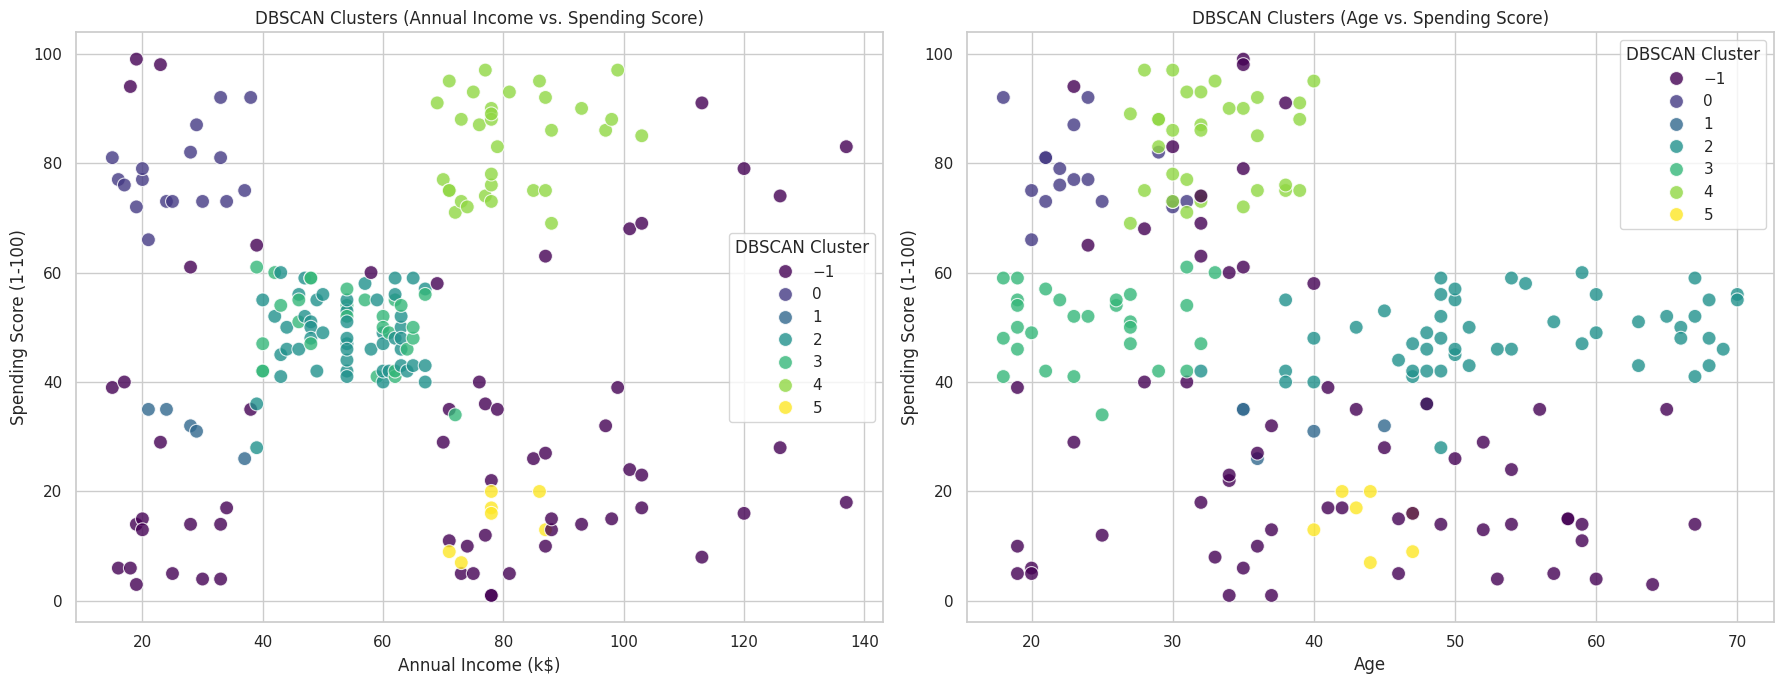

In [18]:
plt.figure(figsize=(18, 7))

plt.subplot(1, 2, 1)
sns.scatterplot(x='Annual_Income', y='Spending_Score', hue='DBSCAN_Cluster', data=df, palette='viridis', s=100, alpha=0.8)
plt.title('DBSCAN Clusters (Annual Income vs. Spending Score)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='DBSCAN Cluster')

plt.subplot(1, 2, 2)
sns.scatterplot(x='Age', y='Spending_Score', hue='DBSCAN_Cluster', data=df, palette='viridis', s=100, alpha=0.8)
plt.title('DBSCAN Clusters (Age vs. Spending Score)')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='DBSCAN Cluster')

plt.tight_layout()
plt.show()

In [19]:
print(df[df['DBSCAN_Cluster'] != -1].groupby('DBSCAN_Cluster').mean())

                   Genre        Age  Annual_Income  Spending_Score
DBSCAN_Cluster                                                    
0               0.529412  23.764706      25.823529       78.176471
1               0.800000  38.200000      27.800000       31.800000
2               0.568627  53.666667      54.156863       48.411765
3               0.607143  24.107143      54.321429       50.464286
4               0.562500  32.750000      80.875000       83.625000
5               0.428571  43.857143      78.714286       14.571429
